# BTYD from zero to useful - PyMC version, no `lifetimes`

This notebook tells the same story as `BTYD_Intro_End_to_End_Project.ipynb`, but removes the `lifetimes` package completely.

We will still do the same BTYD project:

- Generate non-contractual transaction data.
- Build RFM features by hand.
- Fit a BG/NBD transaction model with PyMC-Marketing.
- Fit a Gamma-Gamma spend model with PyMC-Marketing.
- Validate on a holdout window.
- Turn predictions into CLV and a customer action table.

The goal is not to make PyMC look mysterious. The goal is to show that the same business logic can be expressed as a probabilistic model.

Inspiration checked: the Tensor House Bayesian BTYD notebook implements BG/NBD and Gamma-Gamma in PyMC from RFM data. This notebook keeps that spirit, but uses the maintained PyMC-Marketing API so the code is readable for juniors.

## 1. What changes when we move from `lifetimes` to PyMC?

The business problem does not change.

| Question | Same BTYD idea | PyMC version |
|---|---|---|
| Is the customer still active? | `P(alive)` | posterior or MAP estimate from a probabilistic model |
| How many purchases will happen next? | expected future transactions | `BetaGeoModel.expected_purchases()` |
| How much will each purchase be worth? | expected average order value | `GammaGammaModel.expected_customer_spend()` |
| What is expected customer value? | future purchases x expected spend | expected CLV with discounting |

The practical tradeoff:

- `lifetimes` is fast and beginner-friendly.
- PyMC-Marketing is slower but extensible, Bayesian, and uncertainty-aware.

In this notebook we use MAP fitting for speed. MAP is the most likely parameter point under the priors. In production, you can replace MAP with MCMC when uncertainty is important.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

RANDOM_SEED = 20260704
rng = np.random.default_rng(RANDOM_SEED)

from pymc_marketing import clv
from pymc_extras.prior import Prior

## 2. The same story: Bean & Byte coffee customers

We keep the same synthetic business as the `lifetimes` notebook.

The customer can buy whenever they want. There is no cancellation date. Silence might mean churn, or it might just mean the customer is waiting until they need coffee again.

In [2]:
def simulate_transactions(n_customers=650):
    obs_start = pd.Timestamp("2024-01-01")
    obs_end = pd.Timestamp("2025-12-31")
    max_signup_offset = 420

    customer_rows = []
    tx_rows = []

    segment_probs = {
        "Everyday brewer": 0.24,
        "Weekend brewer": 0.42,
        "Gift buyer": 0.22,
        "At-risk sampler": 0.12,
    }
    segments = rng.choice(list(segment_probs), size=n_customers, p=list(segment_probs.values()))

    for i, segment in enumerate(segments, start=1):
        customer_id = f"BB{i:05d}"
        signup_date = obs_start + pd.Timedelta(days=int(rng.integers(0, max_signup_offset)))
        available_days = max((obs_end - signup_date).days, 30)

        if segment == "Everyday brewer":
            annual_orders = rng.gamma(shape=9, scale=1.6)
            dropout_hazard = 0.00035
            mean_order_value = rng.lognormal(mean=np.log(42), sigma=0.25)
        elif segment == "Weekend brewer":
            annual_orders = rng.gamma(shape=5, scale=1.25)
            dropout_hazard = 0.00075
            mean_order_value = rng.lognormal(mean=np.log(34), sigma=0.30)
        elif segment == "Gift buyer":
            annual_orders = rng.gamma(shape=2.2, scale=1.0)
            dropout_hazard = 0.00115
            mean_order_value = rng.lognormal(mean=np.log(62), sigma=0.45)
        else:
            annual_orders = rng.gamma(shape=1.6, scale=1.1)
            dropout_hazard = 0.00230
            mean_order_value = rng.lognormal(mean=np.log(24), sigma=0.35)

        daily_rate = max(annual_orders / 365, 0.001)
        dropout_time = rng.exponential(1 / dropout_hazard)
        alive_until = min(available_days, dropout_time)
        active_at_observation_end = dropout_time > available_days

        order_day = 0
        order_number = 1
        while order_day <= alive_until:
            tx_date = signup_date + pd.Timedelta(days=int(round(order_day)))
            if tx_date > obs_end:
                break
            order_value = float(rng.lognormal(mean=np.log(mean_order_value), sigma=0.30))
            tx_rows.append(
                {
                    "customer_id": customer_id,
                    "invoice_date": tx_date,
                    "order_number": order_number,
                    "sales_value": round(order_value, 2),
                    "segment_hidden_for_simulation": segment,
                }
            )
            order_number += 1
            order_day += rng.exponential(1 / daily_rate)

        customer_rows.append(
            {
                "customer_id": customer_id,
                "segment_hidden_for_simulation": segment,
                "signup_date": signup_date,
                "active_at_observation_end_hidden": active_at_observation_end,
                "latent_annual_order_rate": annual_orders,
                "latent_mean_order_value": mean_order_value,
            }
        )

    transactions = pd.DataFrame(tx_rows).sort_values(["customer_id", "invoice_date"]).reset_index(drop=True)
    customers = pd.DataFrame(customer_rows)
    return transactions, customers, obs_end

transactions, customers, observation_end = simulate_transactions()
print("transactions:", transactions.shape)
print("customers:", customers.shape)
print("observation end:", observation_end.date())
transactions.head()

transactions: (6642, 5)
customers: (650, 6)
observation end: 2025-12-31


,customer_id,invoice_date,order_number,sales_value,segment_hidden_for_simulation
0,BB00001,2024-02-07,1,43.54,Gift buyer
1,BB00001,2024-05-21,2,61.77,Gift buyer
2,BB00001,2024-05-27,3,22.85,Gift buyer
3,BB00001,2024-06-02,4,20.09,Gift buyer
4,BB00001,2024-10-19,5,63.22,Gift buyer


In [3]:
summary = transactions.groupby("customer_id").agg(
    first_purchase=("invoice_date", "min"),
    last_purchase=("invoice_date", "max"),
    orders=("invoice_date", "count"),
    total_revenue=("sales_value", "sum"),
    avg_order_value=("sales_value", "mean"),
).reset_index()
summary["customer_age_days"] = (observation_end - summary["first_purchase"]).dt.days
summary["days_since_last_order"] = (observation_end - summary["last_purchase"]).dt.days
summary.describe().round(2)

,first_purchase,last_purchase,orders,total_revenue,avg_order_value,customer_age_days,days_since_last_order
count,650,650,650.00,650.00,650.00,650.00,650.00
mean,2024-07-18 23:20:07.384615424,2025-06-26 15:52:36.923076864,10.22,436.95,45.41,530.03,187.34
min,2024-01-01 00:00:00,2024-01-02 00:00:00,1.00,10.06,10.06,311.00,0.00
25%,2024-04-09 00:00:00,2025-01-23 12:00:00,3.00,115.72,29.91,432.25,22.25
50%,2024-07-12 00:00:00,2025-09-23 00:00:00,7.00,274.22,39.41,537.00,99.00
75%,2024-10-24 18:00:00,2025-12-08 18:00:00,14.00,613.19,51.65,631.00,341.50
max,2025-02-23 00:00:00,2025-12-31 00:00:00,60.00,2523.59,203.67,730.00,729.00
std,NaN,NaN,9.60,437.69,25.48,120.66,201.08


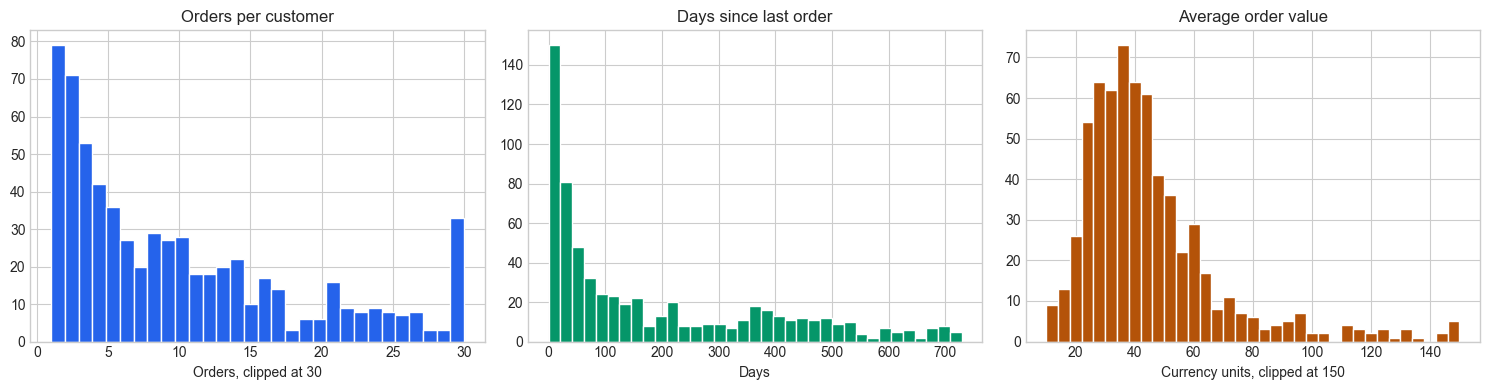

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(summary["orders"].clip(upper=30), bins=30, color="#2563EB", edgecolor="white")
axes[0].set_title("Orders per customer")
axes[0].set_xlabel("Orders, clipped at 30")
axes[1].hist(summary["days_since_last_order"], bins=35, color="#059669", edgecolor="white")
axes[1].set_title("Days since last order")
axes[1].set_xlabel("Days")
axes[2].hist(summary["avg_order_value"].clip(upper=150), bins=35, color="#B45309", edgecolor="white")
axes[2].set_title("Average order value")
axes[2].set_xlabel("Currency units, clipped at 150")
plt.tight_layout()
plt.show()

## 3. Build RFM by hand

This is the first important difference from the previous notebook.

We do not call `lifetimes.utils.summary_data_from_transaction_data`. We compute the BTYD input table ourselves:

- `frequency`: repeat purchases after the first one.
- `recency`: days from first purchase to latest purchase.
- `T`: days from first purchase to observation end.
- `monetary_value`: average value of repeat purchases.

This is worth learning because most real projects have messy definitions: refunds, multiple stores, subscription bundles, fraud, cancelled orders, and time zones.

In [5]:
def build_rfm_by_hand(transactions, observation_end):
    tx = transactions.sort_values(["customer_id", "invoice_date", "order_number"]).copy()
    tx["purchase_rank"] = tx.groupby("customer_id").cumcount() + 1

    customer_summary = tx.groupby("customer_id").agg(
        first_purchase=("invoice_date", "min"),
        last_purchase=("invoice_date", "max"),
        purchases=("invoice_date", "count"),
    )
    customer_summary["frequency"] = customer_summary["purchases"] - 1
    customer_summary["recency"] = (customer_summary["last_purchase"] - customer_summary["first_purchase"]).dt.days.astype(float)
    customer_summary.loc[customer_summary["frequency"].eq(0), "recency"] = 0.0
    customer_summary["T"] = (observation_end - customer_summary["first_purchase"]).dt.days.astype(float)

    repeat_tx = tx[tx["purchase_rank"] > 1]
    monetary = repeat_tx.groupby("customer_id")["sales_value"].mean().rename("monetary_value")
    rfm = customer_summary.join(monetary, how="left")
    rfm["monetary_value"] = rfm["monetary_value"].fillna(0.0)

    out = rfm.reset_index()[["customer_id", "frequency", "recency", "T", "monetary_value"]].copy()
    out["frequency"] = out["frequency"].astype(float)
    return out

rfm = build_rfm_by_hand(transactions, observation_end)
rfm.head(10)

,customer_id,frequency,recency,T,monetary_value
0,BB00001,16.0,594.0,693.0,43.799375
1,BB00002,20.0,573.0,683.0,27.331500
2,BB00003,27.0,470.0,506.0,50.537037
3,BB00004,46.0,599.0,608.0,39.866087
4,BB00005,4.0,542.0,549.0,22.932500
5,BB00006,5.0,199.0,386.0,41.614000
6,BB00007,13.0,369.0,455.0,30.576923
7,BB00008,7.0,434.0,704.0,56.205714
8,BB00009,5.0,321.0,331.0,40.610000
9,BB00010,25.0,670.0,689.0,26.934000


In [6]:
print("Rows:", len(rfm))
print("One-time buyers:", int((rfm["frequency"] == 0).sum()))
print("Repeat buyers:", int((rfm["frequency"] > 0).sum()))
print("Repeat-buyer share:", round((rfm["frequency"] > 0).mean(), 3))
rfm[["frequency", "recency", "T", "monetary_value"]].describe().round(2)

Rows: 650
One-time buyers: 79
Repeat buyers: 571
Repeat-buyer share: 0.878


,frequency,recency,T,monetary_value
count,650.00,650.00,650.00,650.00
mean,9.22,342.69,530.03,39.29
std,9.60,214.54,120.66,26.46
min,0.00,0.00,311.00,0.00
25%,2.00,156.00,432.25,25.70
50%,6.00,363.00,537.00,37.00
75%,13.00,527.75,631.00,49.44
max,59.00,730.00,730.00,196.48


In [7]:
example_customer = rfm.sort_values(["frequency", "T"], ascending=[False, False]).iloc[0]["customer_id"]
example_timeline = transactions[transactions["customer_id"] == example_customer].copy()
print("Example customer:", example_customer)
display(rfm[rfm["customer_id"] == example_customer])
display(example_timeline.head(12))

Example customer: BB00503


,customer_id,frequency,recency,T,monetary_value
502,BB00503,59.0,684.0,686.0,41.784237


,customer_id,invoice_date,order_number,sales_value,segment_hidden_for_simulation
5202,BB00503,2024-02-14,1,47.82,Everyday brewer
5203,BB00503,2024-02-14,2,39.40,Everyday brewer
5204,BB00503,2024-02-28,3,29.22,Everyday brewer
5205,BB00503,2024-03-06,4,28.72,Everyday brewer
5206,BB00503,2024-03-13,5,28.54,Everyday brewer
5207,BB00503,2024-03-17,6,38.63,Everyday brewer
5208,BB00503,2024-04-15,7,49.78,Everyday brewer
5209,BB00503,2024-06-13,8,42.49,Everyday brewer
5210,BB00503,2024-06-20,9,52.61,Everyday brewer
5211,BB00503,2024-07-01,10,59.33,Everyday brewer


## 4. Fit BG/NBD with PyMC-Marketing

BG/NBD models two hidden customer traits:

- purchase rate: how often this customer tends to buy while active.
- dropout probability: whether the customer has quietly stopped buying.

In PyMC, we place priors on the model parameters. A prior is not magic. It is a starting belief that gets updated by data.

We use weak HalfNormal priors because the parameters must be positive and we do not want to overconstrain the model.

In [8]:
model_config = {
    "a": Prior("HalfNormal", sigma=10),
    "b": Prior("HalfNormal", sigma=10),
    "alpha": Prior("HalfNormal", sigma=10),
    "r": Prior("HalfNormal", sigma=10),
}

bgm = clv.BetaGeoModel(data=rfm, model_config=model_config)
bgm.build_model()
bgm.fit(method="map")

print("BG/NBD MAP parameters")
display(bgm.fit_summary().to_frame("value").round(4))

Output()

BG/NBD MAP parameters


,value
alpha,44.101
a,0.111
b,1.933
r,0.934


In [9]:
def mean_over_posterior(xarray_obj):
    return np.asarray(xarray_obj.mean(("chain", "draw")).values).reshape(-1)

expected_purchases = bgm.expected_purchases(future_t=180)
p_alive = bgm.expected_probability_alive()

rfm["expected_purchases_180d"] = mean_over_posterior(expected_purchases)
rfm["p_alive"] = mean_over_posterior(p_alive)

rfm[["expected_purchases_180d", "p_alive"]].describe().round(3)

,expected_purchases_180d,p_alive
count,650.000,650.000
mean,2.845,0.831
std,2.914,0.271
min,0.000,0.000
25%,0.429,0.826
50%,1.854,0.968
75%,4.318,0.990
max,14.559,1.000


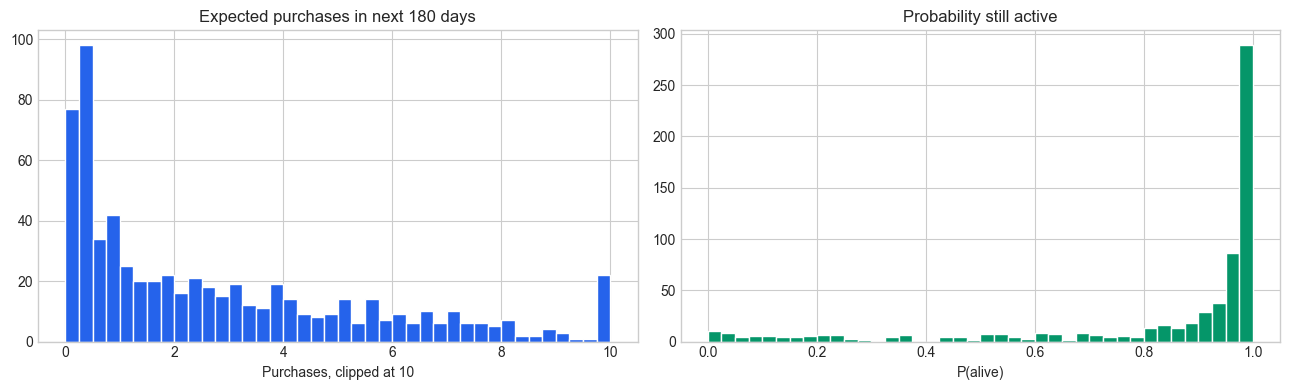

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(rfm["expected_purchases_180d"].clip(upper=10), bins=40, color="#2563EB", edgecolor="white")
axes[0].set_title("Expected purchases in next 180 days")
axes[0].set_xlabel("Purchases, clipped at 10")
axes[1].hist(rfm["p_alive"], bins=40, color="#059669", edgecolor="white")
axes[1].set_title("Probability still active")
axes[1].set_xlabel("P(alive)")
plt.tight_layout()
plt.show()

In [11]:
inspect_cols = ["customer_id", "frequency", "recency", "T", "monetary_value", "expected_purchases_180d", "p_alive"]
rfm.sort_values("expected_purchases_180d", ascending=False)[inspect_cols].head(10).round(3)

,customer_id,frequency,recency,T,monetary_value,expected_purchases_180d,p_alive
502,BB00503,59.0,684.0,686.0,41.784,14.559,0.998
90,BB00091,41.0,453.0,469.0,44.109,14.314,0.990
338,BB00339,31.0,339.0,350.0,32.834,14.147,0.992
175,BB00176,32.0,388.0,388.0,35.516,13.399,0.997
3,BB00004,46.0,599.0,608.0,39.866,12.718,0.995
356,BB00357,45.0,544.0,588.0,39.153,12.092,0.938
561,BB00562,24.0,311.0,317.0,36.272,12.056,0.993
178,BB00179,39.0,537.0,545.0,49.471,11.959,0.995
156,BB00157,41.0,561.0,578.0,44.380,11.857,0.992
368,BB00369,32.0,440.0,445.0,38.335,11.847,0.995


## 5. Validate with a calibration and holdout split

We still need a backtest.

This time we cannot use the `lifetimes` calibration helper. We manually:

1. Keep transactions up to the calibration date.
2. Build RFM from that earlier history.
3. Fit BG/NBD on calibration RFM.
4. Predict purchases in the holdout window.
5. Compare with actual holdout purchases.

In [12]:
calibration_end = observation_end - pd.Timedelta(days=180)
cal_tx = transactions[transactions["invoice_date"] <= calibration_end].copy()
holdout_tx = transactions[(transactions["invoice_date"] > calibration_end) & (transactions["invoice_date"] <= observation_end)].copy()

cal_rfm = build_rfm_by_hand(cal_tx, calibration_end)
holdout_counts = holdout_tx.groupby("customer_id").size().rename("frequency_holdout")
cal_rfm = cal_rfm.merge(holdout_counts, on="customer_id", how="left")
cal_rfm["frequency_holdout"] = cal_rfm["frequency_holdout"].fillna(0.0)

bgm_cal = clv.BetaGeoModel(data=cal_rfm, model_config=model_config)
bgm_cal.build_model()
bgm_cal.fit(method="map")

holdout_days = (observation_end - calibration_end).days
cal_rfm["predicted_holdout_purchases"] = mean_over_posterior(bgm_cal.expected_purchases(future_t=holdout_days))

eval_df = cal_rfm.replace([np.inf, -np.inf], np.nan).dropna(subset=["frequency_holdout", "predicted_holdout_purchases"])
mae = np.mean(np.abs(eval_df["frequency_holdout"] - eval_df["predicted_holdout_purchases"]))
rmse = np.sqrt(np.mean((eval_df["frequency_holdout"] - eval_df["predicted_holdout_purchases"]) ** 2))
rank_corr = eval_df[["frequency_holdout", "predicted_holdout_purchases"]].corr(method="spearman").iloc[0, 1]

print(f"Holdout window: {holdout_days} days")
print(f"Evaluated customers: {len(eval_df):,} of {len(cal_rfm):,}")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"Spearman rank correlation: {rank_corr:.3f}")
eval_df[["frequency", "recency", "T", "frequency_holdout", "predicted_holdout_purchases"]].head()

Output()

Holdout window: 180 days
Evaluated customers: 650 of 650
MAE: 1.674
RMSE: 2.341
Spearman rank correlation: 0.767


,frequency,recency,T,frequency_holdout,predicted_holdout_purchases
0,12.0,474.0,513.0,4.0,4.077860
1,17.0,477.0,503.0,3.0,5.775261
2,17.0,316.0,326.0,10.0,8.503488
3,33.0,425.0,428.0,13.0,12.699819
4,2.0,215.0,369.0,2.0,1.142712


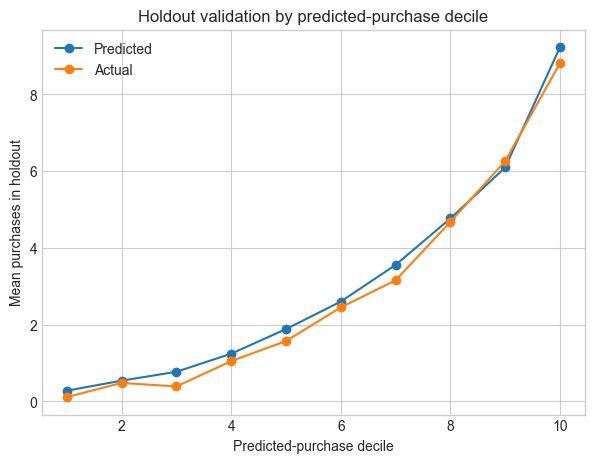

,customers,predicted_purchases,actual_purchases
0,65,0.275,0.108
1,65,0.536,0.477
2,65,0.768,0.385
3,65,1.240,1.046
4,65,1.881,1.569
5,65,2.599,2.446
6,65,3.555,3.154
7,65,4.767,4.677
8,65,6.097,6.262
9,65,9.235,8.815


In [13]:
plot_df = eval_df.copy()
plot_df["pred_bin"] = pd.qcut(plot_df["predicted_holdout_purchases"], q=10, duplicates="drop")
calibration_table = plot_df.groupby("pred_bin", observed=True).agg(
    customers=("frequency_holdout", "size"),
    predicted_purchases=("predicted_holdout_purchases", "mean"),
    actual_purchases=("frequency_holdout", "mean"),
).reset_index()

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(calibration_table.index + 1, calibration_table["predicted_purchases"], marker="o", label="Predicted")
ax.plot(calibration_table.index + 1, calibration_table["actual_purchases"], marker="o", label="Actual")
ax.set_title("Holdout validation by predicted-purchase decile")
ax.set_xlabel("Predicted-purchase decile")
ax.set_ylabel("Mean purchases in holdout")
ax.legend()
plt.show()
calibration_table[["customers", "predicted_purchases", "actual_purchases"]].round(3)

## 6. Fit Gamma-Gamma with PyMC-Marketing

Gamma-Gamma estimates the expected average order value.

We only fit it on repeat customers with positive monetary value. That is not a software quirk; the model needs an observed repeat-purchase average to learn customer-level spend.

In [14]:
repeat_customers = rfm[(rfm["frequency"] > 0) & (rfm["monetary_value"] > 0)].copy()
frequency_monetary_corr = repeat_customers[["frequency", "monetary_value"]].corr().iloc[0, 1]
print(f"Correlation between frequency and monetary_value: {frequency_monetary_corr:.3f}")

gg = clv.GammaGammaModel(data=repeat_customers)
gg.build_model()
gg.fit(method="map")

print("Gamma-Gamma MAP parameters")
display(gg.fit_summary().to_frame("value").round(4))

expected_spend = gg.expected_customer_spend(data=repeat_customers)
repeat_customers["expected_avg_order_value"] = mean_over_posterior(expected_spend)
repeat_customers[["monetary_value", "expected_avg_order_value"]].describe().round(2)

Correlation between frequency and monetary_value: -0.102


Output()

Gamma-Gamma MAP parameters


,value
p,2.713
q,12.013
v,175.240


,monetary_value,expected_avg_order_value
count,571.00,571.00
mean,44.72,43.21
std,23.52,10.87
min,9.28,21.82
25%,30.92,36.33
50%,39.50,41.09
75%,50.54,47.85
max,196.48,98.75


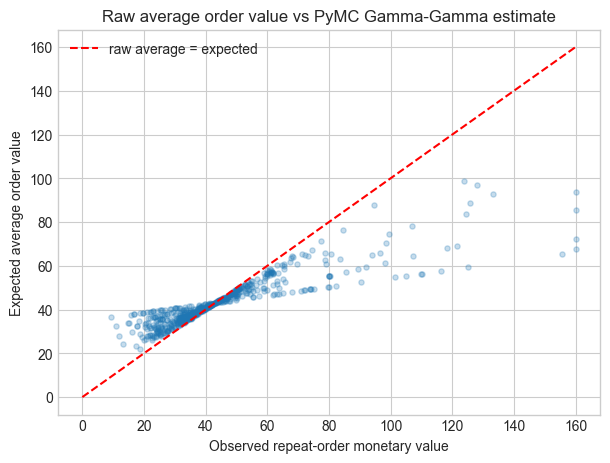

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    repeat_customers["monetary_value"].clip(upper=160),
    repeat_customers["expected_avg_order_value"].clip(upper=160),
    alpha=0.25,
    s=14,
)
ax.plot([0, 160], [0, 160], color="red", linestyle="--", label="raw average = expected")
ax.set_title("Raw average order value vs PyMC Gamma-Gamma estimate")
ax.set_xlabel("Observed repeat-order monetary value")
ax.set_ylabel("Expected average order value")
ax.legend()
plt.show()

## 7. Estimate CLV without `lifetimes`

PyMC-Marketing combines the transaction model and spend model for us.

Because we used MAP, the result has one chain and one draw. With MCMC, this same call would return a distribution of CLV values per customer, which is the main Bayesian advantage.

In [16]:
clv_estimate = gg.expected_customer_lifetime_value(
    transaction_model=bgm,
    data=rfm,
    future_t=6,
    discount_rate=0.01,
    time_unit="D",
)

rfm["clv_6m"] = mean_over_posterior(clv_estimate)
rfm["expected_avg_order_value"] = np.nan
spend_all = gg.expected_customer_spend(data=rfm)
rfm["expected_avg_order_value"] = mean_over_posterior(spend_all)

repeat_scored = rfm[(rfm["frequency"] > 0) & (rfm["monetary_value"] > 0)].copy()
repeat_scored[["expected_purchases_180d", "expected_avg_order_value", "p_alive", "clv_6m"]].describe().round(2)

,expected_purchases_180d,expected_avg_order_value,p_alive,clv_6m
count,571.00,571.00,571.00,571.00
mean,3.20,43.21,0.81,131.72
std,2.94,10.87,0.28,127.22
min,0.00,21.82,0.00,0.01
25%,0.82,36.33,0.77,32.88
50%,2.36,41.09,0.95,92.74
75%,4.97,47.85,0.99,192.08
max,14.56,98.75,1.00,608.81


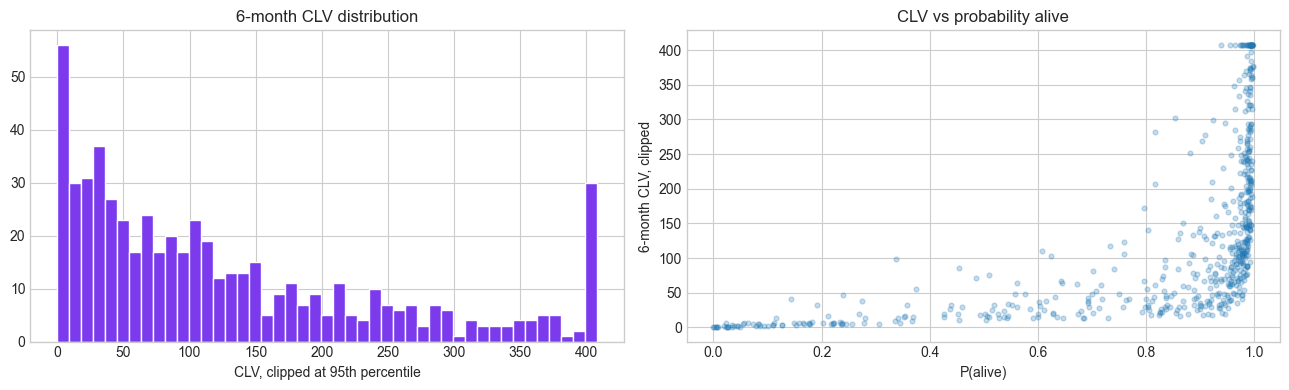

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(repeat_scored["clv_6m"].clip(upper=repeat_scored["clv_6m"].quantile(0.95)), bins=45, color="#7C3AED", edgecolor="white")
axes[0].set_title("6-month CLV distribution")
axes[0].set_xlabel("CLV, clipped at 95th percentile")
axes[1].scatter(repeat_scored["p_alive"], repeat_scored["clv_6m"].clip(upper=repeat_scored["clv_6m"].quantile(0.95)), alpha=0.25, s=12)
axes[1].set_title("CLV vs probability alive")
axes[1].set_xlabel("P(alive)")
axes[1].set_ylabel("6-month CLV, clipped")
plt.tight_layout()
plt.show()

In [18]:
repeat_scored.sort_values("clv_6m", ascending=False)[
    ["customer_id", "frequency", "recency", "T", "monetary_value", "expected_purchases_180d", "p_alive", "expected_avg_order_value", "clv_6m"]
].head(12).round(2)

,customer_id,frequency,recency,T,monetary_value,expected_purchases_180d,p_alive,expected_avg_order_value,clv_6m
90,BB00091,41.0,453.0,469.0,44.11,14.31,0.99,44.02,608.81
502,BB00503,59.0,684.0,686.0,41.78,14.56,1.00,41.87,588.95
178,BB00179,39.0,537.0,545.0,49.47,11.96,1.00,48.88,564.67
439,BB00440,26.0,603.0,664.0,94.78,6.46,0.96,87.81,547.82
203,BB00204,26.0,369.0,384.0,52.72,10.98,0.99,51.43,545.48
268,BB00269,28.0,389.0,405.0,49.70,11.25,0.99,48.88,531.18
277,BB00278,38.0,701.0,713.0,59.79,9.10,0.99,58.19,511.32
156,BB00157,41.0,561.0,578.0,44.38,11.86,0.99,44.27,507.12
3,BB00004,46.0,599.0,608.0,39.87,12.72,1.00,40.13,493.08
36,BB00037,34.0,542.0,559.0,50.04,10.18,0.99,49.30,485.03


## 8. Turn PyMC output into the same action table

The model changed, but the business decision layer stays familiar:

- High CLV and high P(alive): protect.
- High CLV and low P(alive): win back.
- Low CLV and high P(alive): nurture cheaply.
- Low CLV and low P(alive): low-touch.

In [19]:
scorecard = repeat_scored.copy()
scorecard["clv_percentile"] = scorecard["clv_6m"].rank(pct=True)
scorecard["p_alive_percentile"] = scorecard["p_alive"].rank(pct=True)
conditions = [
    (scorecard["clv_percentile"] >= 0.80) & (scorecard["p_alive"] >= 0.75),
    (scorecard["clv_percentile"] >= 0.80) & (scorecard["p_alive"] < 0.75),
    (scorecard["clv_percentile"] < 0.80) & (scorecard["p_alive"] >= 0.75),
]
choices = [
    "Protect: high value and active",
    "Win back: valuable but fading",
    "Nurture cheaply: active but lower value",
]
scorecard["recommended_action"] = np.select(conditions, choices, default="Low-touch: low value or inactive")
scorecard.groupby("recommended_action").agg(
    customers=("customer_id", "count"),
    avg_clv_6m=("clv_6m", "mean"),
    avg_p_alive=("p_alive", "mean"),
    avg_expected_purchases_180d=("expected_purchases_180d", "mean"),
).sort_values("avg_clv_6m", ascending=False).round(2)

,customers,avg_clv_6m,avg_p_alive,avg_expected_purchases_180d
recommended_action,,,,
Protect: high value and active,115,344.63,0.98,7.67
Nurture cheaply: active but lower value,317,102.35,0.94,2.73
Low-touch: low value or inactive,139,22.55,0.37,0.55


## 9. What we gained and what we paid

What we gained:

- No dependency on `lifetimes`.
- Direct probabilistic model objects.
- A path to posterior uncertainty and custom priors.
- A path to hierarchical or covariate-rich BTYD models.

What we paid:

- More dependencies.
- More fitting time.
- More statistical responsibility.

A good workflow is: learn the mechanics with `lifetimes`, then move to PyMC when uncertainty, priors, or model customization matter.

## Final consultant summary

We rebuilt the same BTYD project without `lifetimes`. We manually built RFM, fitted BG/NBD and Gamma-Gamma through PyMC-Marketing, validated future purchase predictions on a holdout window, estimated CLV, and translated the model into customer actions.

The modeling mindset is unchanged: BTYD is still about repeat purchases, hidden dropout, expected spend, and decision quality. PyMC simply gives us a more extensible probabilistic engine.